# Análisis de E-Commerce Olist
## Exploración y Análisis de Datos (EDA)

**Dataset:** [Brazilian E-Commerce - Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Objetivo:** Analizar patrones de ventas, tiempos de entrega, estacionalidad e ingresos por estado.

In [1]:
# Importo las librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path

In [2]:
# Me conecto a la base de datos local

DB_PATH = Path("../data/olist.db")
engine = create_engine(f"sqlite:///{DB_PATH}")

In [3]:
# Exploración inicial

tablas = ["orders", "order_items", "order_payments", 
          "order_reviews", "customers", "products", 
          "sellers", "product_category_translation", "geolocation"]

with engine.connect() as conn:
    for tabla in tablas:
        resultado = pd.read_sql(text(f"SELECT COUNT(*) as filas FROM {tabla}"), conn)
        print(f"{tabla}: {resultado['filas'][0]:,} filas")

orders: 99,441 filas
order_items: 112,650 filas
order_payments: 103,886 filas
order_reviews: 99,224 filas
customers: 99,441 filas
products: 32,951 filas
sellers: 3,095 filas
product_category_translation: 71 filas
geolocation: 1,000,163 filas


In [4]:
# Vistazo general a las 5 primeras filas de las tablas principales

with engine.connect() as conn:
    for tabla in ["orders", "order_items", "customers", "products"]:
        df = pd.read_sql(text(f"SELECT * FROM {tabla} LIMIT 5"), conn)
        print(f"\n{'='*60}")
        print(f"TABLA: {tabla}")
        print(f"{'='*60}")
        display(df)


TABLA: orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



TABLA: order_items


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



TABLA: customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



TABLA: products


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


## ¿Cuáles son las categorías más vendidas?

In [5]:
# Creo la query para traerme la información que necesito

query = """
    SELECT 
	COUNT(order_id) AS cantidad_vendida,
	pct.product_category_name_english AS categoria
FROM order_items AS oi
JOIN products AS p ON oi.product_id = p.product_id
JOIN product_category_translation pct ON p.product_category_name = pct.product_category_name
GROUP BY categoria
ORDER BY cantidad_vendida DESC
"""

with engine.connect() as conn:
    df_categorias = pd.read_sql(text(query), conn)

df_categorias.info() # Reviso que no hayan valores nulos
df_categorias.head(10) # Las 10 categorías más vendidas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   cantidad_vendida  71 non-null     int64 
 1   categoria         71 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.2+ KB


,cantidad_vendida,categoria
0,11115,bed_bath_table
1,9670,health_beauty
2,8641,sports_leisure
3,8334,furniture_decor
4,7827,computers_accessories
5,6964,housewares
6,5991,watches_gifts
7,4545,telephony
8,4347,garden_tools
9,4235,auto


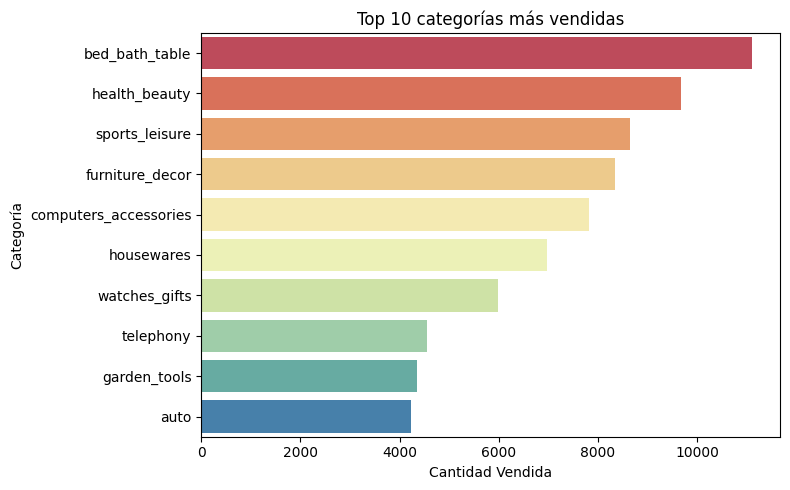

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data= df_categorias.head(10), x="cantidad_vendida", y="categoria", hue="categoria", palette="Spectral", legend=False)
plt.title("Top 10 categorías más vendidas")
plt.xlabel("Cantidad Vendida")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

## ¿Cuánto tarda en promedio la entrega?

In [7]:
query = """
SELECT 
	order_purchase_timestamp AS fecha_de_compra,
	order_delivered_customer_date AS fecha_de_entrega
FROM orders
"""

with engine.connect() as conn:
    df_entregas = pd.read_sql(text(query), conn)

df_entregas.info() # Hay nulos
df_entregas.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   fecha_de_compra   99441 non-null  object
 1   fecha_de_entrega  96476 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


,fecha_de_compra,fecha_de_entrega
0,2017-10-02 10:56:33,2017-10-10 21:25:13
1,2018-07-24 20:41:37,2018-08-07 15:27:45
2,2018-08-08 08:38:49,2018-08-17 18:06:29
3,2017-11-18 19:28:06,2017-12-02 00:28:42
4,2018-02-13 21:18:39,2018-02-16 18:17:02


Hay algunos nulos y las fechas no están en datetime

In [8]:
# Me deshago de los nulos y convierto las fechas a tipo fecha

df_entregas = df_entregas.dropna()
df_entregas["fecha_de_compra"] = pd.to_datetime(df_entregas["fecha_de_compra"])
df_entregas["fecha_de_entrega"] = pd.to_datetime(df_entregas["fecha_de_entrega"])

# Creo la columna "días de entrega"

df_entregas["dias_entrega"] = (df_entregas["fecha_de_entrega"] - df_entregas["fecha_de_compra"]).dt.days

# Verifico

df_entregas.head()

,fecha_de_compra,fecha_de_entrega,dias_entrega
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2


In [9]:
df_entregas["dias_entrega"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: dias_entrega, dtype: float64

- Vemos que en promedio, la entrega tarda 12 días. Sin embargo, también se ve como el máximo tiempo de entrega es 209 días, claro outlier.
- Otra cosa cosa que llama la atención es que el mínimo es de 0 días. Aunque es posible que fueran pedidos comprados y entregados el mismo día.

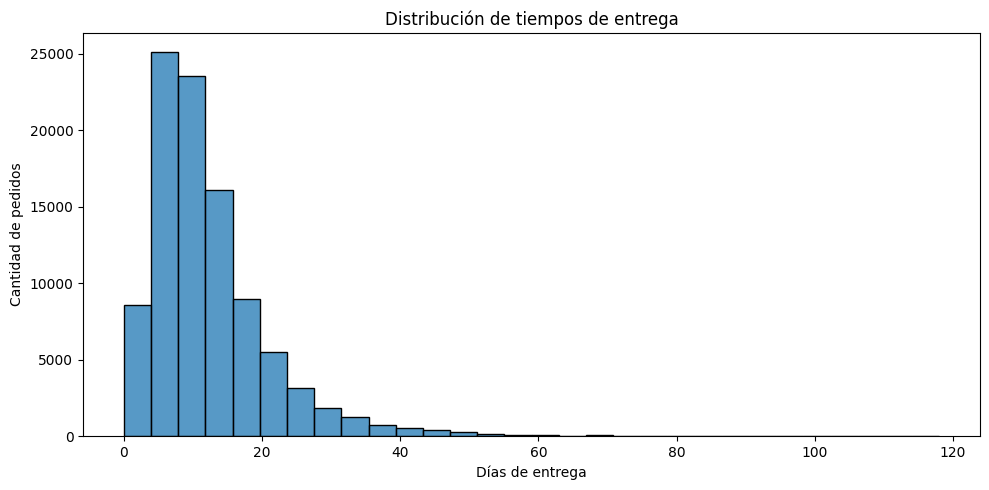

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_entregas[df_entregas["dias_entrega"] <= 120], x="dias_entrega", bins=30)
plt.title("Distribución de tiempos de entrega")
plt.xlabel("Días de entrega")
plt.ylabel("Cantidad de pedidos")
plt.tight_layout()
plt.show()

Después de 70 días es cuando empíezan los números raros

In [11]:

# Reviso cuántos pedidos se entregaron el mismo día

print(df_entregas[df_entregas["dias_entrega"] == 0].shape[0])

13


13 es insignificante, así que no lo filtro

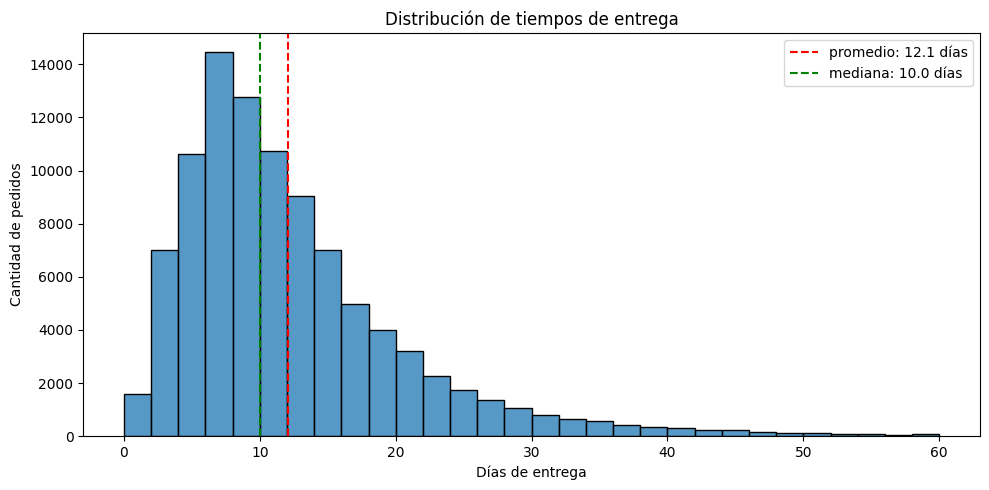

In [12]:
promedio = df_entregas["dias_entrega"].mean()
mediana = df_entregas["dias_entrega"].median()

plt.figure(figsize=(10, 5))
sns.histplot(data=df_entregas[df_entregas["dias_entrega"] <= 60], x="dias_entrega", bins=30)
plt.axvline(promedio, color="red", linestyle="--", label=f"promedio: {promedio:.1f} días")
plt.axvline(mediana, color="green", linestyle="--", label=f"mediana: {mediana:.1f} días")
plt.title("Distribución de tiempos de entrega")
plt.xlabel("Días de entrega")
plt.ylabel("Cantidad de pedidos")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Creo un resumen de este DataFrame para no exportar los datos crudos
 
resumen_entregas = pd.DataFrame({
    "metrica": ["Promedio", "Mediana", "Percentil 25", "Percentil 75", "Máximo"],
    "dias": [
        df_entregas["dias_entrega"].mean(),
        df_entregas["dias_entrega"].median(),
        df_entregas["dias_entrega"].quantile(0.25),
        df_entregas["dias_entrega"].quantile(0.75),
        df_entregas["dias_entrega"].max()
    ]
})

resumen_entregas

,metrica,dias
0,Promedio,12.094086
1,Mediana,10.000000
2,Percentil 25,6.000000
3,Percentil 75,15.000000
4,Máximo,209.000000


## ¿Hay estacionalidad en las ventas?

In [14]:
query = """
SELECT order_purchase_timestamp AS fecha_de_compra
FROM orders
"""

with engine.connect() as conn:
    df_estacionalidad = pd.read_sql(text(query), conn)

df_estacionalidad.info() # Sin nulos
df_estacionalidad.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   fecha_de_compra  99441 non-null  object
dtypes: object(1)
memory usage: 777.0+ KB


,fecha_de_compra
0,2017-10-02 10:56:33
1,2018-07-24 20:41:37
2,2018-08-08 08:38:49
3,2017-11-18 19:28:06
4,2018-02-13 21:18:39


In [15]:
df_estacionalidad["fecha_de_compra"] = pd.to_datetime(df_estacionalidad["fecha_de_compra"]) # Cambio dtype a datetime
df_estacionalidad["anio_mes"] = df_estacionalidad["fecha_de_compra"].dt.to_period("M") # Creo una columna que divida por meses

df_estacionalidad = df_estacionalidad.groupby("anio_mes")["fecha_de_compra"].count().reset_index() # Agrupo por la columna anio_mes y cuento las ordenes
df_estacionalidad.columns = ["anio_mes", "cantidad_ordenes"] # Renombro las columnas
df_estacionalidad

,anio_mes,cantidad_ordenes
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


- Los primeros y últimos datos tomados son muy pocos, es mejor filtrar esas fechas para no distorsionar el gráfico

In [16]:
df_estacionalidad = df_estacionalidad[(df_estacionalidad["anio_mes"] >= "2017-01") & (df_estacionalidad["anio_mes"] <= "2018-08")]

# Acá vuelvo a convertir la columna anio_mes a texto para que seaborn tome bien los datos al crear el gráfico
df_estacionalidad["anio_mes"] = df_estacionalidad["anio_mes"].astype(str)

C:\Users\augus\AppData\Local\Temp\ipykernel_3636\2153090480.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_estacionalidad["anio_mes"] = df_estacionalidad["anio_mes"].astype(str)


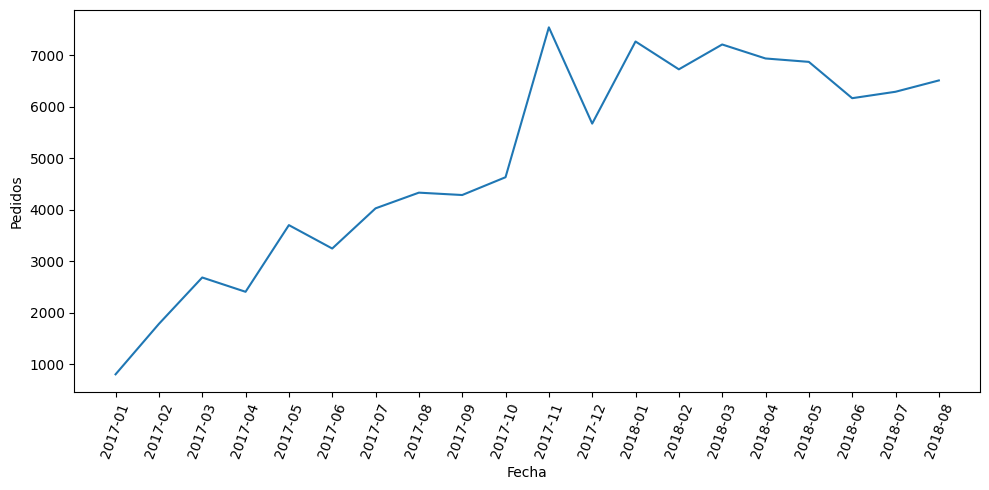

In [17]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_estacionalidad, x="anio_mes", y="cantidad_ordenes")
plt.xlabel("Fecha")
plt.ylabel("Pedidos")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

## ¿Qué estados de Brasil generan más ingresos?

In [18]:
query = """
SELECT 
	customer_state AS estado,
	sum(price) AS ingresos
FROM orders AS o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY estado
ORDER BY ingresos DESC
"""

with engine.connect() as conn:
    df_estados = pd.read_sql(text(query), conn)

df_estados.info() # Sin nulos
df_estados.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   estado    27 non-null     object 
 1   ingresos  27 non-null     float64
dtypes: float64(1), object(1)
memory usage: 564.0+ bytes


,estado,ingresos
0,SP,5.202955e+06
1,RJ,1.824093e+06
2,MG,1.585308e+06
3,RS,7.503040e+05
4,PR,6.830838e+05


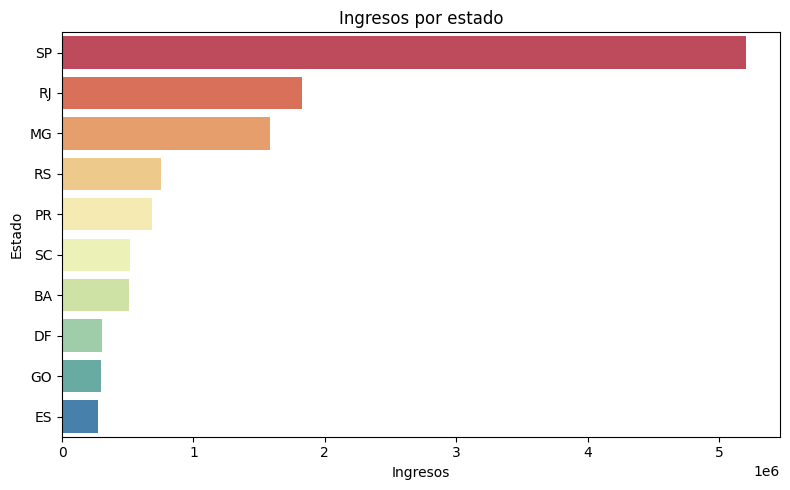

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data= df_estados.head(10), x="ingresos", y="estado", hue="estado", palette="Spectral", legend=False)
plt.title("Ingresos por estado")
plt.xlabel("Ingresos")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()

In [20]:
OUTPUT_PATH = Path("../dashboard/dashboard.xlsx")

if OUTPUT_PATH.exists():
    print("El dashboard ya existe. No se exportó nada.")
else:
    with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
        df_categorias.to_excel(writer, sheet_name="categorias", index=False)
        resumen_entregas.to_excel(writer, sheet_name="entregas", index=False)
        df_estacionalidad.to_excel(writer, sheet_name="estacionalidad", index=False)
        df_estados.to_excel(writer, sheet_name="estados", index=False)

    print("✅ Dashboard exportado")

El dashboard ya existe. No se exportó nada.


## Conclusiones

### 1. Categorías más vendidas
Las categorías de **cama/baño/mesa**, **salud/belleza** y **deportes/ocio** lideran las ventas, concentrando una proporción significativa del volumen total. Esto refleja que Olist tiene una base de clientes orientada al hogar y el bienestar personal.

### 2. Tiempos de entrega
El tiempo promedio de entrega es de **12 días**, con una mediana de **10 días**. Hay algunos outliers que superan los 60 días. Para un e-commerce, 10-12 días es un tiempo elevado comparado con estándares internacionales. Esto podría significar que existe una oportunidad de mejora logística.

### 3. Estacionalidad
Las ventas crecieron de forma sostenida durante 2017 con un pico en noviembre (Black Friday), para luego estabilizarse en torno a las 6.000–7.000 órdenes mensuales en 2018. La plataforma pasó de una fase de expansión a una de madurez.

### 4. Ingresos por estado
**São Paulo concentra más del doble de ingresos** que el segundo estado (Río de Janeiro), seguido por Minas Gerais. Esto refleja la concentración económica histórica de Brasil y podría indicar que hay mucho mercado sin explotar.